**Exploratory Data Analysis**

In [2]:
import sys
print("Python:", sys.executable)

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import scipy.stats as stats
import statsmodels.api as sm

PROJECT_ROOT = Path("D://Ahmed//Credit_Loan_Risk")
RAW_DATA_PATH   = PROJECT_ROOT / "dataset" / "applications_dataset.csv"
EDA_OUTPUT_PATH = PROJECT_ROOT / "reports" / "eda"
FIGURE_PATH     = PROJECT_ROOT / "reports" / "figures"
# Misc constants used throughout the notebook
RANDOM_STATE   = 94
TARGET_COL     = "TARGET"
ID_COL         = "SK_ID_CURR"
DAYS_EMPLOYED_ANOMALY = 365_243
# Make sure the output folders exist
EDA_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)
# Optional – handy display settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Python: d:\Ahmed\Credit_Loan_Risk\.venv\Scripts\python.exe


In [3]:

df = pd.read_csv(RAW_DATA_PATH, low_memory=False)


df["EMPLOYED_SENTINEL"] = (df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_ANOMALY).astype(int)
df.loc[df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_ANOMALY, "DAYS_EMPLOYED"] = pd.NA

print("Data shape :", df.shape)
df.head()


Data shape : (307511, 123)


C:\Users\ahmed\AppData\Local\Temp\ipykernel_30012\1061182676.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYED_SENTINEL"] = (df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_ANOMALY).astype(int)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EMPLOYED_SENTINEL
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:

col_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "unique": [df[c].nunique(dropna=True) for c in df.columns],
    "sample_vals": [
        ", ".join(map(str, df[c].dropna().unique()[:5]))
        for c in df.columns
    ],
})

# Show first rows
col_dict.head()
# Save for later reference
col_dict.to_csv(EDA_OUTPUT_PATH / "column_dictionary.csv", index=False)


In [5]:
# Duplicate rows based on the unique application id
# ------------------------------------------------------------------

dup_rows = df.duplicated(subset=[ID_COL]).sum()
dup_summary = pd.DataFrame({
    "duplicate_rows": [dup_rows],
    "total_rows":    [len(df)],
    "unique_rows":   [len(df) - dup_rows],
})

dup_summary
dup_summary.to_csv(EDA_OUTPUT_PATH / "duplicate_summary.csv", index=False)


In [6]:
# Detailed statistics for every column
# ------------------------------------------------------------------
import pandas as pd
import numpy as np


percentiles = [0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]


def detailed_stats(series: pd.Series) -> pd.Series:
    """Return a series with min, max, mean, std, and the custom percentiles."""
    if series.dtype.kind in "bifc":          # numeric / boolean / float / complex
        q = series.quantile(percentiles, interpolation="nearest")
        return pd.Series({
            "count":        series.count(),
            "missing":      series.isna().sum(),
            "missing_pct":  100 * series.isna().mean(),
            "min":          series.min(),
            "max":          series.max(),
            "mean":         series.mean(),
            "std":          series.std(),
            **{f"pct_{int(p*100)}": v for p, v in zip(percentiles, q)}
        })
    else:                                    # non‑numeric (object, category, bool)
        # For categorical data we give count, uniques and top‑k frequencies
        top = series.value_counts().nlargest(5)
        top_str = "; ".join([f"{idx}:{cnt}" for idx, cnt in top.items()])
        return pd.Series({
            "count":        series.count(),
            "missing":      series.isna().sum(),
            "missing_pct":  100 * series.isna().mean(),
            "unique":       series.nunique(dropna=True),
            "top_5":        top_str,
        })

# Apply the helper to every column
stats_df = pd.concat([detailed_stats(df[col]).rename(col) for col in df.columns],
                    axis=1).T


numeric_cols = stats_df[stats_df["mean"].notna()].index.tolist()
categorical_cols = [c for c in stats_df.index if c not in numeric_cols]
ordered = numeric_cols + categorical_cols
stats_df = stats_df.loc[ordered]


stats_df.to_csv(EDA_OUTPUT_PATH / "detailed_statistics.csv")

print(f" Detailed statistics saved to {EDA_OUTPUT_PATH / 'detailed_statistics.csv'}")


 Detailed statistics saved to D:\Ahmed\Credit_Loan_Risk\reports\eda\detailed_statistics.csv


In [7]:
missing_threshold = 0.50
missing_pct = df.isna().mean()
cols_to_drop = missing_pct[missing_pct > missing_threshold].index.tolist()

# Sanity check: how do these correlate with target before dropping?
for col in cols_to_drop:
    if df[col].dtype != 'object':
        flag = df[col].isna().astype(int)
        corr = flag.corr(df[TARGET_COL])
        if abs(corr) > 0.05:  # arbitrary "worth a second look" cutoff
            print(f" {col}: missingness correlates with target ({corr:.3f}) — consider keeping as a flag")

In [8]:
cols_to_keep_anyway = ["OWN_CAR_AGE", "EXT_SOURCE_1"]  # columns to protect from dropping

missing_pct = df.isna().mean()
cols_to_drop = [
    col for col in missing_pct[missing_pct > missing_threshold].index
    if col not in cols_to_keep_anyway
]

print(f"Dropping {len(cols_to_drop)} columns with >{missing_threshold*100}% missing:")
print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

Dropping 39 columns with >50.0% missing:
['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


In [9]:
print(df.shape)

(307511, 84)


In [10]:
# Impute CAR_AGE only where FLAG_OWN_CAR == "Y"
# ------------------------------------------------------------------
# First make sure the flag is numeric (0/1) for easier logic
df["FLAG_OWN_CAR_NUM"] = (df["FLAG_OWN_CAR"] == "Y").astype(int)

# Sentinel: ‑1 (outside any realistic age in days)
sentinel = -1

df["CAR_AGE_IMPUTED"] = df["OWN_CAR_AGE"]                     # copy original
df.loc[df["FLAG_OWN_CAR_NUM"] == 0, "CAR_AGE_IMPUTED"] = sentinel   # no car → sentinel
df.loc[df["FLAG_OWN_CAR_NUM"] == 1, "CAR_AGE_IMPUTED"] = (
    df.loc[df["FLAG_OWN_CAR_NUM"] == 1, "OWN_CAR_AGE"]
    .fillna(df["OWN_CAR_AGE"].median())                      # or any other strategy
)


df.drop(columns=["OWN_CAR_AGE", "FLAG_OWN_CAR"], inplace=True)

In [11]:
# ------------------------------------------------------------------
# Impute EXT_SOURCE_1: flag missingness, then fill with median
# ------------------------------------------------------------------
df["EXT_SOURCE_1_MISSING"] = df["EXT_SOURCE_1"].isna().astype(int)

df["EXT_SOURCE_1_IMPUTED"] = df["EXT_SOURCE_1"].fillna(
    df["EXT_SOURCE_1"].median()
)

# Drop the original now that it's fully captured by the two new columns
df.drop(columns=["EXT_SOURCE_1"], inplace=True)

In [12]:
def impute_column(col_name, strategy="median"):
    """
    Impute a numeric column after the missing‑indicator has been added.
    strategy: "median", "mean", or "constant"
    """
    if strategy == "median":
        fill_val = df[col_name].median()
    elif strategy == "mean":
        fill_val = df[col_name].mean()
    elif strategy == "constant":
        fill_val = -1          # sentinel for “not applicable”
    else:
        raise ValueError("Unsupported strategy")
    
    df[col_name] = df[col_name].fillna(fill_val)

# Example usage:
impute_column("DAYS_EMPLOYED")          # simple median fill
impute_column("AMT_ANNUITY")
impute_column("AMT_GOODS_PRICE")
impute_column("EXT_SOURCE_2")
impute_column("EXT_SOURCE_3")
impute_column("CNT_FAM_MEMBERS")
impute_column("OBS_30_CNT_SOCIAL_CIRCLE")
impute_column("DEF_30_CNT_SOCIAL_CIRCLE")
impute_column("OBS_60_CNT_SOCIAL_CIRCLE")
impute_column("DEF_60_CNT_SOCIAL_CIRCLE")
impute_column("DAYS_LAST_PHONE_CHANGE")

bureau_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
]
df["BUREAU_REQ_MISSING"] = df["AMT_REQ_CREDIT_BUREAU_YEAR"].isna().astype(int)
for col in bureau_cols:
    df[col] = df[col].fillna(df[col].median())

mode_value = df["NAME_TYPE_SUITE"].mode()[0]
df["NAME_TYPE_SUITE"] = df["NAME_TYPE_SUITE"].fillna(mode_value)

df.loc[df["OCCUPATION_TYPE"].isna() & (df["EMPLOYED_SENTINEL"] == 1), "OCCUPATION_TYPE"] = "Not_Employed"
df.loc[df["OCCUPATION_TYPE"].isna(), "OCCUPATION_TYPE"] = "Unknown"

In [13]:
df.drop(columns=["FLOORSMAX_AVG", "YEARS_BEGINEXPLUATATION_AVG","YEARS_BEGINEXPLUATATION_MODE","FLOORSMAX_MODE","YEARS_BEGINEXPLUATATION_MEDI","FLOORSMAX_MEDI","TOTALAREA_MODE","EMERGENCYSTATE_MODE"], inplace=True)
print(df.shape)

(307511, 78)


**ANALYSIS AFTER DEALING WITH DEAD COLUMNS**

In [14]:
# Apply the helper to every column
stats_df = pd.concat([detailed_stats(df[col]).rename(col) for col in df.columns],
                    axis=1).T


numeric_cols = stats_df[stats_df["mean"].notna()].index.tolist()
categorical_cols = [c for c in stats_df.index if c not in numeric_cols]
ordered = numeric_cols + categorical_cols
stats_df = stats_df.loc[ordered]


stats_df.to_csv(EDA_OUTPUT_PATH / "detailed_statistics_cleaned.csv")

print(f" Detailed statistics saved to {EDA_OUTPUT_PATH / 'detailed_statistics_cleaned.csv'}")
output_path = PROJECT_ROOT / "Dataset" / "non_NA_df.csv"
df.to_csv(output_path, index=False)

 Detailed statistics saved to D:\Ahmed\Credit_Loan_Risk\reports\eda\detailed_statistics_cleaned.csv


**OUTLIER REMOVAL**

In [15]:
days_cols = [
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"
]

amt_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

count_cols = [
    "CNT_CHILDREN",
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE",
]

print("=== DAYS columns ===")
print(df[days_cols].describe().T[["min", "max"]])

print("\n=== AMT columns ===")
print(df[amt_cols].describe().T[["min", "max", "mean", "50%"]])

print("\n=== COUNT columns ===")
print(df[count_cols].describe().T[["min", "max", "mean", "50%"]])

print("\n=== CAR_AGE_IMPUTED ===")
print(df["CAR_AGE_IMPUTED"].describe())

=== DAYS columns ===
                            min     max
DAYS_BIRTH             -25229.0 -7489.0
DAYS_EMPLOYED          -17912.0     0.0
DAYS_REGISTRATION      -24672.0     0.0
DAYS_ID_PUBLISH         -7197.0     0.0
DAYS_LAST_PHONE_CHANGE  -4292.0     0.0

=== AMT columns ===
                      min          max           mean       50%
AMT_INCOME_TOTAL  25650.0  117000000.0  168797.919297  147150.0
AMT_CREDIT        45000.0    4050000.0  599025.999706  513531.0
AMT_ANNUITY        1615.5     258025.5   27108.487841   24903.0
AMT_GOODS_PRICE   40500.0    4050000.0  538316.294367  450000.0

=== COUNT columns ===
                          min    max      mean  50%
CNT_CHILDREN              0.0   19.0  0.417052  0.0
OBS_30_CNT_SOCIAL_CIRCLE  0.0  348.0  1.417523  0.0
DEF_30_CNT_SOCIAL_CIRCLE  0.0   34.0  0.142944  0.0
OBS_60_CNT_SOCIAL_CIRCLE  0.0  344.0  1.400626  0.0
DEF_60_CNT_SOCIAL_CIRCLE  0.0   24.0  0.099717  0.0

=== CAR_AGE_IMPUTED ===
count    307511.000000
mean          3

In [16]:
# ------------------------------------------------------------------
# Outlier capping
# ------------------------------------------------------------------

# 1. AMT columns — cap at 99th percentile
for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)
    print(f"{col}: capped at {upper:,.1f}")

# 2. CNT_CHILDREN — hard cap at 5
df["CNT_CHILDREN"] = df["CNT_CHILDREN"].clip(upper=5)

# 3. Social circle counts — cap at 99th percentile
for col in ["OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
            "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"]:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)
    print(f"{col}: capped at {upper:,.1f}")

# 4. CAR_AGE_IMPUTED — cap only real values (exclude -1 sentinel)
car_mask = df["CAR_AGE_IMPUTED"] != -1
upper_car = df.loc[car_mask, "CAR_AGE_IMPUTED"].quantile(0.99)
df.loc[car_mask, "CAR_AGE_IMPUTED"] = df.loc[car_mask, "CAR_AGE_IMPUTED"].clip(upper=upper_car)
print(f"CAR_AGE_IMPUTED: capped real values at {upper_car:.1f}")

AMT_INCOME_TOTAL: capped at 472,500.0
AMT_CREDIT: capped at 1,854,000.0
AMT_ANNUITY: capped at 70,006.5
AMT_GOODS_PRICE: capped at 1,800,000.0
OBS_30_CNT_SOCIAL_CIRCLE: capped at 10.0
DEF_30_CNT_SOCIAL_CIRCLE: capped at 2.0
OBS_60_CNT_SOCIAL_CIRCLE: capped at 10.0
DEF_60_CNT_SOCIAL_CIRCLE: capped at 2.0
CAR_AGE_IMPUTED: capped real values at 64.0


**ONE HOT ENCODING**

In [17]:
cat_cols = df.select_dtypes(include="object").columns
print(df[cat_cols].nunique().sort_values(ascending=False))

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               20
NAME_INCOME_TYPE               8
WEEKDAY_APPR_PROCESS_START     7
NAME_TYPE_SUITE                7
NAME_HOUSING_TYPE              6
NAME_FAMILY_STATUS             6
NAME_EDUCATION_TYPE            5
CODE_GENDER                    3
FLAG_OWN_REALTY                2
NAME_CONTRACT_TYPE             2
dtype: int64


C:\Users\ahmed\AppData\Local\Temp\ipykernel_30012\2922146908.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [18]:
# ------------------------------------------------------------------
# 1. Drop XNA gender rows
# ------------------------------------------------------------------
df = df[df["CODE_GENDER"] != "XNA"].reset_index(drop=True)

# ------------------------------------------------------------------
# 2. Binary encode (2-value columns → 0/1)
# ------------------------------------------------------------------
df["CODE_GENDER"]       = (df["CODE_GENDER"] == "M").astype(int)        # M=1, F=0
df["FLAG_OWN_REALTY"]   = (df["FLAG_OWN_REALTY"] == "Y").astype(int)    # Y=1, N=0
df["NAME_CONTRACT_TYPE"] = (df["NAME_CONTRACT_TYPE"] == "Cash loans").astype(int)  # Cash=1, Revolving=0

# ------------------------------------------------------------------
# 3. Label encode (ordinal)
# ------------------------------------------------------------------
education_order = {
    "Lower secondary"   : 0,
    "Secondary / secondary special" : 1,
    "Incomplete higher" : 2,
    "Higher education"  : 3,
    "Academic degree"   : 4,
}
df["NAME_EDUCATION_TYPE"] = df["NAME_EDUCATION_TYPE"].map(education_order)

# ------------------------------------------------------------------
# 4. One-hot encode (low-cardinality, no ordering)
# ------------------------------------------------------------------
ohe_cols = [
    "OCCUPATION_TYPE",
    "NAME_INCOME_TYPE",
    "WEEKDAY_APPR_PROCESS_START",
    "NAME_TYPE_SUITE",
    "NAME_HOUSING_TYPE",
    "NAME_FAMILY_STATUS",
]

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df.shape}")
print(f"Any remaining object columns: {df.select_dtypes(include='object').columns.tolist()}")

Shape after encoding: (307507, 120)
Any remaining object columns: ['ORGANIZATION_TYPE']


C:\Users\ahmed\AppData\Local\Temp\ipykernel_30012\1211235035.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Any remaining object columns: {df.select_dtypes(include='object').columns.tolist()}")


In [19]:
# How many defaults vs. repaid?
# ------------------------------------------------------------------
target_counts = (
    df[TARGET_COL]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)

target_counts["percent"] = (
    target_counts["count"] / target_counts["count"].sum() * 100
)

target_counts
target_counts.to_csv(EDA_OUTPUT_PATH / "target_distribution.csv", index=False)

# Bar chart
sns.barplot(x="target", y="count", data=target_counts, palette="viridis")
plt.title("Target distribution")
plt.xlabel("TARGET (0 = repaid, 1 = default)")
plt.savefig(FIGURE_PATH / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.clf()


C:\Users\ahmed\AppData\Local\Temp\ipykernel_30012\554157963.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="target", y="count", data=target_counts, palette="viridis")


<Figure size 1000x600 with 0 Axes>

**TRAIN TEST SPLIT**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["TARGET", "ORGANIZATION_TYPE"])  
y = df["TARGET"]
org_type = df["ORGANIZATION_TYPE"]  # keep separate for target encoding later

X_train, X_test, y_train, y_test, org_train, org_test = train_test_split(
    X, y, org_type,
    test_size=0.2,
    random_state=912,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target rate — Train: {y_train.mean():.4f}, Test: {y_test.mean():.4f}")

Train: (246005, 118), Test: (61502, 118)
Target rate — Train: 0.0807, Test: 0.0807


In [21]:
days_cols = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE"
]

for col in days_cols:
    X_train[col] = X_train[col].abs()
    X_test[col]  = X_test[col].abs()

In [22]:
# ------------------------------------------------------------------
# Target encode ORGANIZATION_TYPE (fit on train only)
# ------------------------------------------------------------------
# Compute mean target rate per category on training data only
target_encoding_map = y_train.groupby(org_train.values).mean()

# Apply to both train and test
X_train["ORGANIZATION_TYPE"] = org_train.map(target_encoding_map)
X_test["ORGANIZATION_TYPE"]  = org_test.map(target_encoding_map)

# Sanity check — should be no NaNs unless test has unseen categories
print("NaNs in ORGANIZATION_TYPE after encoding:")
print(f"  Train: {X_train['ORGANIZATION_TYPE'].isna().sum()}")
print(f"  Test:  {X_test['ORGANIZATION_TYPE'].isna().sum()}")

print("\nSample of encoding map (category → default rate):")
print(target_encoding_map.sort_values(ascending=False).head(10))

NaNs in ORGANIZATION_TYPE after encoding:
  Train: 0
  Test:  0

Sample of encoding map (category → default rate):
Transport: type 3    0.160169
Industry: type 8     0.157895
Restaurant           0.118384
Industry: type 13    0.117647
Construction         0.115191
Cleaning             0.114833
Industry: type 1     0.112981
Realtor              0.111111
Industry: type 3     0.109470
Agriculture          0.103764
Name: TARGET, dtype: float64


**CORRELATION ANALYSIS**

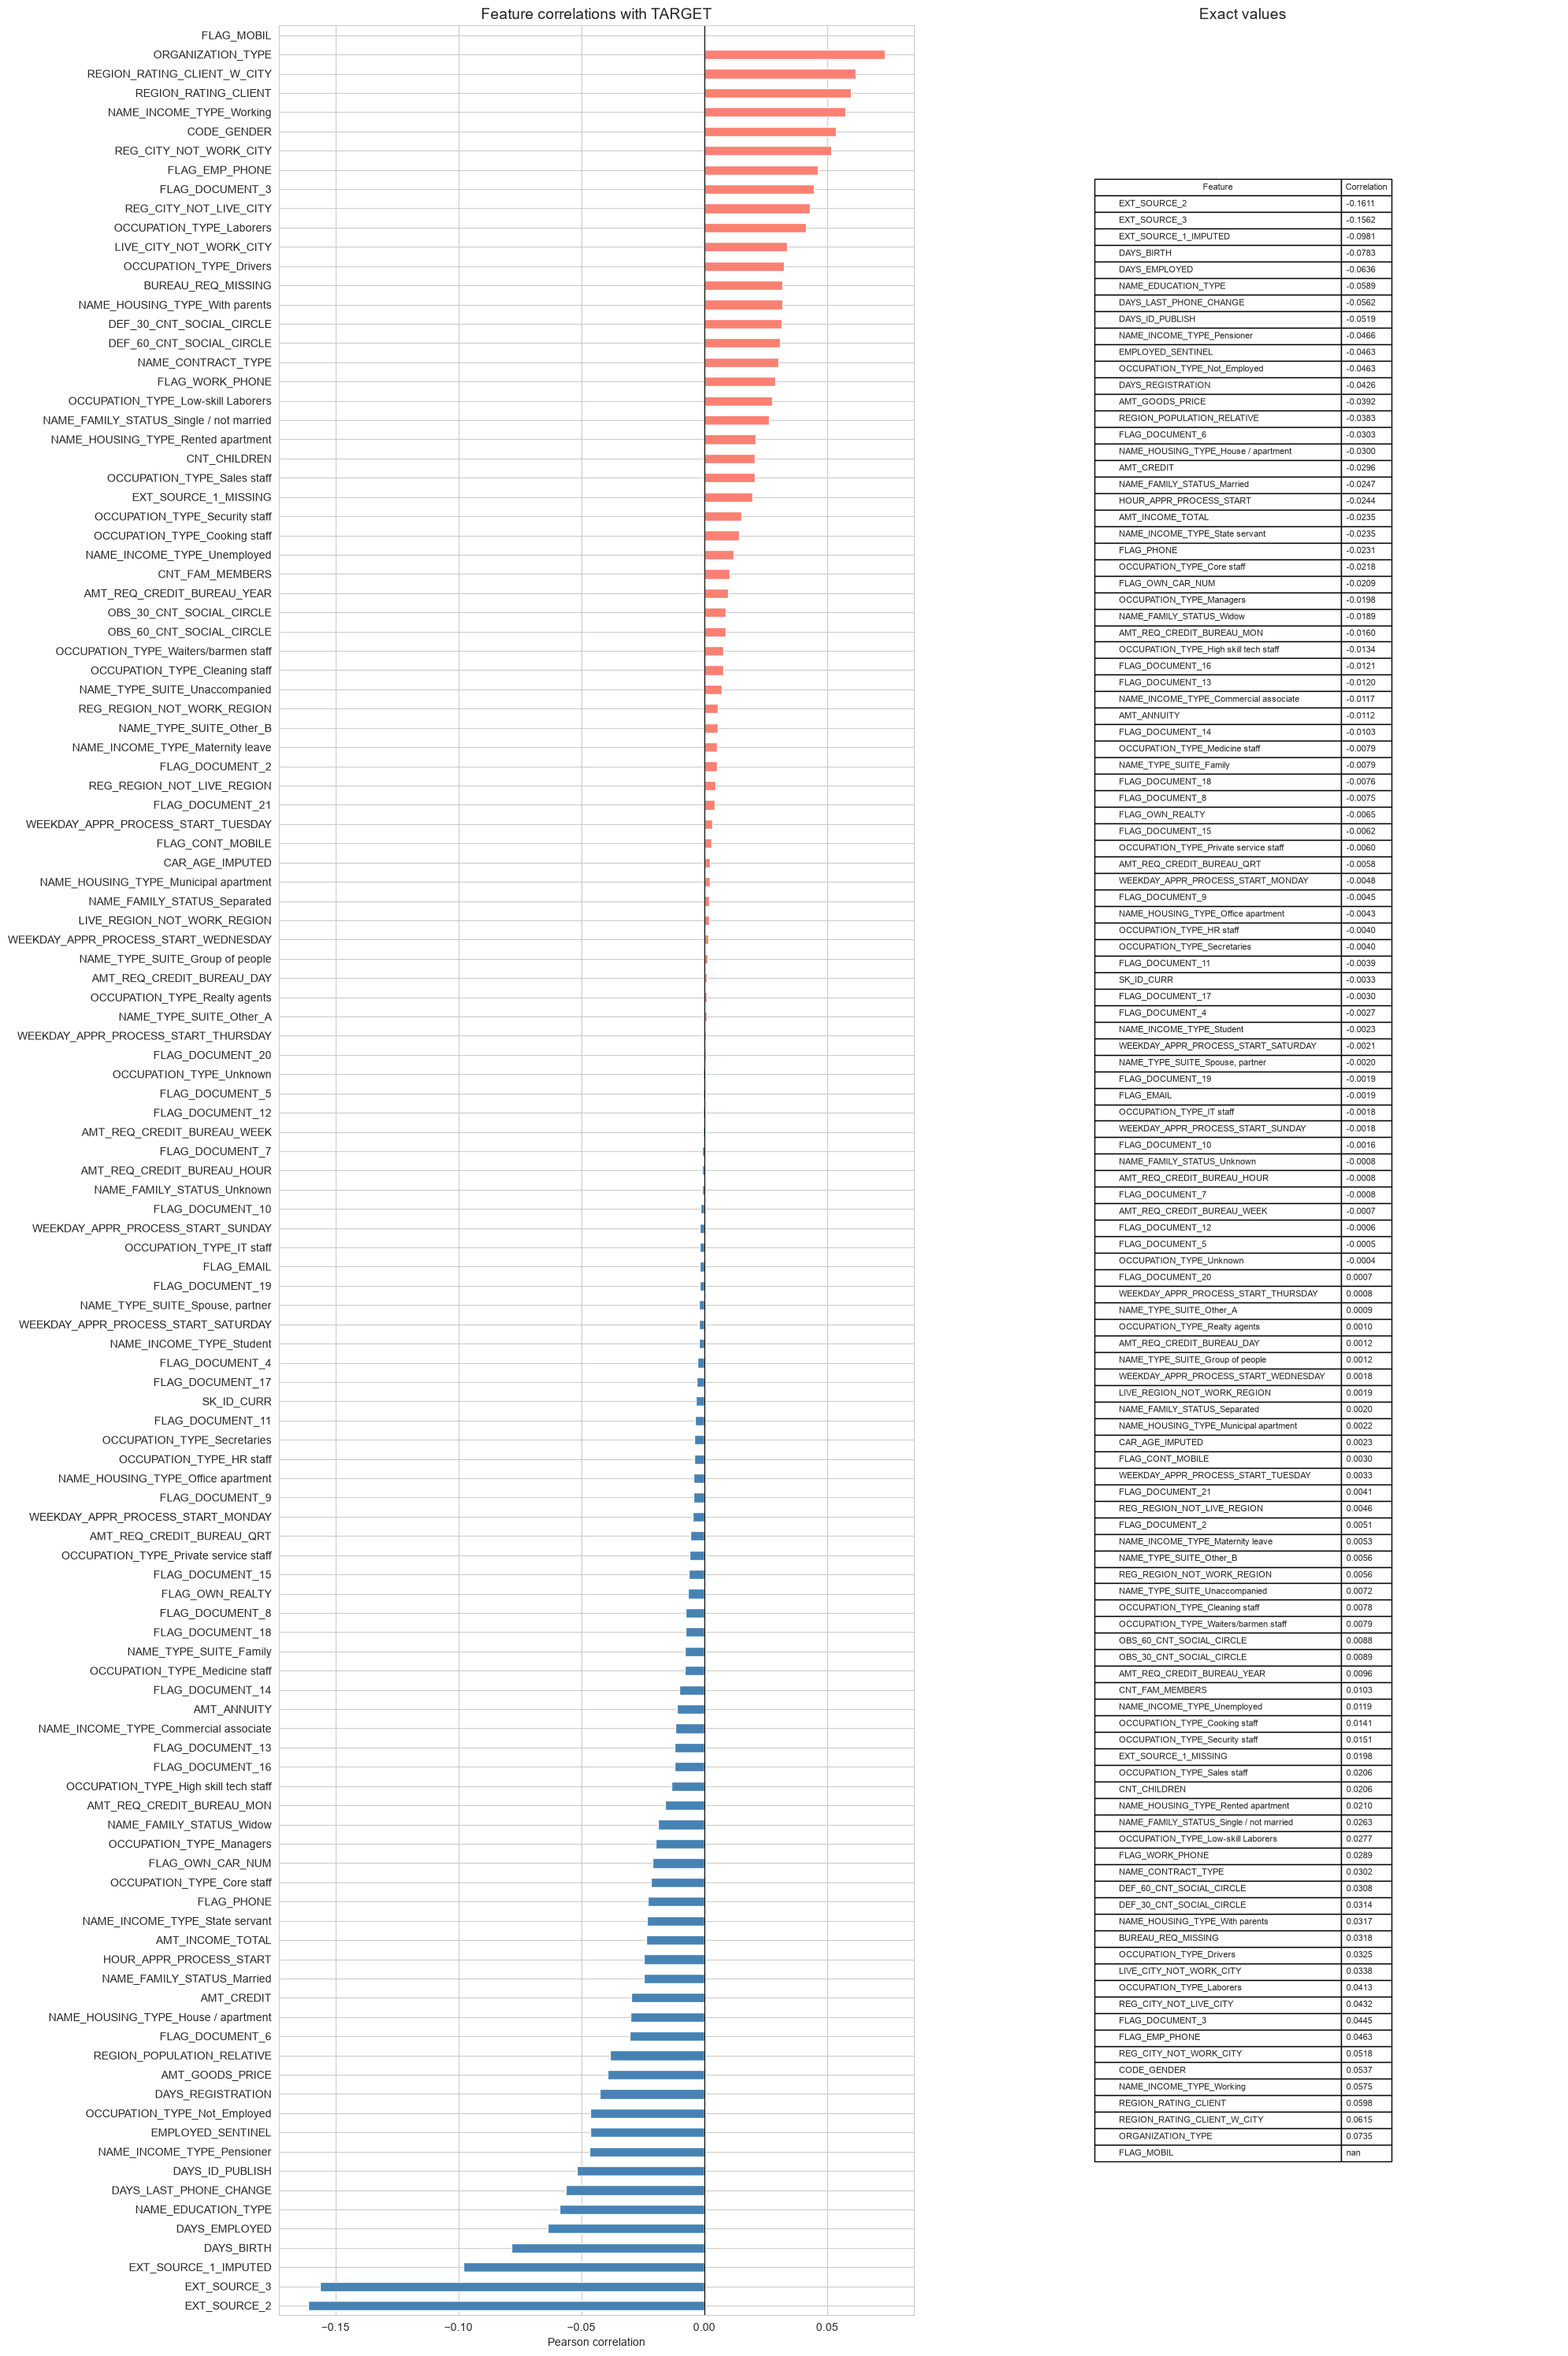


=== Pairs with correlation > 0.9 (6 pairs) ===
  OCCUPATION_TYPE_Not_Employed ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ OCCUPATION_TYPE_Not_Employed: 1.000
  OBS_60_CNT_SOCIAL_CIRCLE ↔ OBS_30_CNT_SOCIAL_CIRCLE: 0.998
  AMT_GOODS_PRICE ↔ AMT_CREDIT: 0.986
  REGION_RATING_CLIENT_W_CITY ↔ REGION_RATING_CLIENT: 0.951

=== Pairs with correlation > 0.8 (10 pairs) ===
  OCCUPATION_TYPE_Not_Employed ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ OCCUPATION_TYPE_Not_Employed: 1.000
  OBS_60_CNT_SOCIAL_CIRCLE ↔ OBS_30_CNT_SOCIAL_CIRCLE: 0.998
  AMT_GOODS_PRICE ↔ AMT_CREDIT: 0.986
  REGION_RATING_CLIENT_W_CITY ↔ REGION_RATING_CLIENT: 0.951
  CNT_FAM_MEMBERS ↔ CNT_CHILDREN: 0.878
  LIVE_REGION_NOT_WORK_REGION ↔ REG_REGION_NOT_WORK_REGION: 0.860
  DEF_60_CNT_SOCIAL_CIRCLE ↔ DEF_30_CNT_SOCIAL_CIRCLE: 0.852
  LIVE_CITY_NOT_WORK_CITY ↔ REG_CITY_NOT_WORK_CITY: 0.82

In [23]:
# ------------------------------------------------------------------
# 1. Target correlation — full sorted bar chart + numbers
# ------------------------------------------------------------------
train_full = X_train.copy()
train_full["TARGET"] = y_train.values
corr_matrix = train_full.corr()

target_corr = corr_matrix["TARGET"].drop("TARGET").sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 30))

# Bar chart
colors = ["salmon" if v > 0 else "steelblue" for v in target_corr]
target_corr.plot(kind="barh", ax=ax1, color=colors)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_title("Feature correlations with TARGET", fontsize=14)
ax1.set_xlabel("Pearson correlation")

# Numbers table
ax2.axis("off")
table_data = [[feat, f"{val:.4f}"] for feat, val in target_corr.items()]
table = ax2.table(
    cellText=table_data,
    colLabels=["Feature", "Correlation"],
    loc="center",
    cellLoc="left"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width([0, 1])
ax2.set_title("Exact values", fontsize=14)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "target_correlations.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 2. Feature pairs at multiple thresholds
# ------------------------------------------------------------------
upper = corr_matrix.drop(columns="TARGET").drop(index="TARGET")
upper = upper.where(np.triu(np.ones(upper.shape), k=1).astype(bool))

for threshold in [0.90, 0.80, 0.70, 0.60]:
    pairs = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold
    ]
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    print(f"\n=== Pairs with correlation > {threshold} ({len(pairs)} pairs) ===")
    for col1, col2, val in pairs:
        print(f"  {col1} ↔ {col2}: {val:.3f}")

In [24]:
print("=== Top 20 NEGATIVE correlations with TARGET ===")
print(target_corr.head(20).to_string())

print("\n=== Top 20 POSITIVE correlations with TARGET ===")
print(target_corr.tail(20).to_string())

=== Top 20 NEGATIVE correlations with TARGET ===
EXT_SOURCE_2                          -0.161127
EXT_SOURCE_3                          -0.156226
EXT_SOURCE_1_IMPUTED                  -0.098141
DAYS_BIRTH                            -0.078328
DAYS_EMPLOYED                         -0.063627
NAME_EDUCATION_TYPE                   -0.058907
DAYS_LAST_PHONE_CHANGE                -0.056181
DAYS_ID_PUBLISH                       -0.051924
NAME_INCOME_TYPE_Pensioner            -0.046557
EMPLOYED_SENTINEL                     -0.046271
OCCUPATION_TYPE_Not_Employed          -0.046268
DAYS_REGISTRATION                     -0.042634
AMT_GOODS_PRICE                       -0.039246
REGION_POPULATION_RELATIVE            -0.038300
FLAG_DOCUMENT_6                       -0.030295
NAME_HOUSING_TYPE_House / apartment   -0.030030
AMT_CREDIT                            -0.029572
NAME_FAMILY_STATUS_Married            -0.024669
HOUR_APPR_PROCESS_START               -0.024437
AMT_INCOME_TOTAL                      -

In [25]:
# Find all zero-variance columns
zero_var_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]
print(f"Zero variance columns: {zero_var_cols}")

# Drop from both train and test
X_train.drop(columns=zero_var_cols, inplace=True)
X_test.drop(columns=zero_var_cols, inplace=True)

print(f"Dropped {len(zero_var_cols)} columns. New shape: {X_train.shape}")

Zero variance columns: ['FLAG_MOBIL']
Dropped 1 columns. New shape: (246005, 118)


In [26]:
# ------------------------------------------------------------------
#  Engineer new features FIRST (before any drops)
# ------------------------------------------------------------------
for df_ in [X_train, X_test]:
    # Loan burden relative to income
    df_["ANNUITY_INCOME_RATIO"]  = df_["AMT_ANNUITY"]  / df_["AMT_INCOME_TOTAL"]
    df_["CREDIT_INCOME_RATIO"]   = df_["AMT_CREDIT"]   / df_["AMT_INCOME_TOTAL"]

    # Implied loan duration in months
    df_["CREDIT_TERM"]           = df_["AMT_CREDIT"]   / df_["AMT_ANNUITY"]

    # Employment as fraction of life
    df_["EMPLOYED_TO_AGE_RATIO"] = df_["DAYS_EMPLOYED"] / df_["DAYS_BIRTH"]

    # Loan amount vs goods price
    df_["CREDIT_TO_GOODS_RATIO"] = df_["AMT_CREDIT"]   / df_["AMT_GOODS_PRICE"]

    # Address instability score
    df_["ADDRESS_MISMATCH"]      = (
        df_["REG_CITY_NOT_WORK_CITY"] +
        df_["REG_CITY_NOT_LIVE_CITY"] +
        df_["LIVE_CITY_NOT_WORK_CITY"]
    )

    # Social circle default rate (needs OBS_60 — must be before drops)
    df_["SOCIAL_DEFAULT_RATE_30"] = (
        df_["DEF_30_CNT_SOCIAL_CIRCLE"] / (df_["OBS_30_CNT_SOCIAL_CIRCLE"] + 1e-5)
    )
    df_["SOCIAL_DEFAULT_RATE_60"] = (
        df_["DEF_60_CNT_SOCIAL_CIRCLE"] / (df_["OBS_60_CNT_SOCIAL_CIRCLE"] + 1e-5)
    )

print("Engineered features added:")
new_features = [
    "ANNUITY_INCOME_RATIO", "CREDIT_INCOME_RATIO", "CREDIT_TERM",
    "EMPLOYED_TO_AGE_RATIO", "CREDIT_TO_GOODS_RATIO", "ADDRESS_MISMATCH",
    "SOCIAL_DEFAULT_RATE_30", "SOCIAL_DEFAULT_RATE_60"
]
print(X_train[new_features].describe().T[["min", "max", "mean"]])

Engineered features added:
                             min        max       mean
ANNUITY_INCOME_RATIO    0.008700   1.875965   0.180815
CREDIT_INCOME_RATIO     0.095238  72.280702   3.957792
CREDIT_TERM             6.324539  59.560354  21.610575
EMPLOYED_TO_AGE_RATIO   0.000000   0.728811   0.142454
CREDIT_TO_GOODS_RATIO   0.150000   6.000000   1.121947
ADDRESS_MISMATCH        0.000000   3.000000   0.488523
SOCIAL_DEFAULT_RATE_30  0.000000   0.999995   0.065742
SOCIAL_DEFAULT_RATE_60  0.000000   0.999995   0.049783


In [27]:
# ------------------------------------------------------------------
#  Drop redundant columns
# ------------------------------------------------------------------
cols_to_drop_redundant = [
    "EMPLOYED_SENTINEL",                # perfect overlap with NAME_INCOME_TYPE_Pensioner
    "OCCUPATION_TYPE_Not_Employed",     # perfect overlap with NAME_INCOME_TYPE_Pensioner
    "OBS_60_CNT_SOCIAL_CIRCLE",         # 0.998 with OBS_30, replaced by SOCIAL_DEFAULT_RATE_60
    "REGION_RATING_CLIENT",             # 0.951 with REGION_RATING_CLIENT_W_CITY
    "LIVE_REGION_NOT_WORK_REGION",      # 0.860 with REG_REGION_NOT_WORK_REGION
    "CNT_FAM_MEMBERS",                  # 0.878 with CNT_CHILDREN
]

X_train.drop(columns=cols_to_drop_redundant, inplace=True)
X_test.drop(columns=cols_to_drop_redundant, inplace=True)

print(f"Dropped {len(cols_to_drop_redundant)} redundant columns. Shape: {X_train.shape}")

Dropped 6 redundant columns. Shape: (246005, 120)


In [28]:
# ------------------------------------------------------------------
# Drop columns replaced by engineered features
# ------------------------------------------------------------------
cols_to_drop_replaced = [
    "AMT_GOODS_PRICE",          # replaced by CREDIT_TO_GOODS_RATIO
    "LIVE_CITY_NOT_WORK_CITY",  # absorbed into ADDRESS_MISMATCH
    "REG_CITY_NOT_LIVE_CITY",   # absorbed into ADDRESS_MISMATCH
    "REG_CITY_NOT_WORK_CITY",   # absorbed into ADDRESS_MISMATCH
    "DEF_30_CNT_SOCIAL_CIRCLE", # replaced by SOCIAL_DEFAULT_RATE_30
    "DEF_60_CNT_SOCIAL_CIRCLE", # replaced by SOCIAL_DEFAULT_RATE_60
]

X_train.drop(columns=cols_to_drop_replaced, inplace=True)
X_test.drop(columns=cols_to_drop_replaced, inplace=True)

print(f"Dropped {len(cols_to_drop_replaced)} replaced columns. Shape: {X_train.shape}")

Dropped 6 replaced columns. Shape: (246005, 114)


In [29]:
# ------------------------------------------------------------------
#Sanity check
# ------------------------------------------------------------------
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nAny NaNs in X_train: {X_train.isna().sum().sum()}")
print(f"Any NaNs in X_test:  {X_test.isna().sum().sum()}")
print(f"\nAny inf values in X_train: {np.isinf(X_train).sum().sum()}")
print(f"Any inf values in X_test:  {np.isinf(X_test).sum().sum()}")
print(f"\nRemaining object columns: {X_train.select_dtypes(include='object').columns.tolist()}")

X_train shape: (246005, 114)
X_test shape:  (61502, 114)

Any NaNs in X_train: 0
Any NaNs in X_test:  0

Any inf values in X_train: 0
Any inf values in X_test:  0

Remaining object columns: []


In [30]:
ratio_cols = [
    "ANNUITY_INCOME_RATIO", "CREDIT_INCOME_RATIO", "CREDIT_TERM",
    "EMPLOYED_TO_AGE_RATIO", "CREDIT_TO_GOODS_RATIO",
    "SOCIAL_DEFAULT_RATE_30", "SOCIAL_DEFAULT_RATE_60"
]

new_feature_corrs = X_train[ratio_cols].corrwith(y_train).sort_values()
print(new_feature_corrs)

EMPLOYED_TO_AGE_RATIO    -0.049812
CREDIT_TERM              -0.031855
CREDIT_INCOME_RATIO      -0.006711
ANNUITY_INCOME_RATIO      0.015276
SOCIAL_DEFAULT_RATE_60    0.026380
SOCIAL_DEFAULT_RATE_30    0.027807
CREDIT_TO_GOODS_RATIO     0.069329
dtype: float64


In [31]:
full_corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(full_corr.to_string())

EXT_SOURCE_2                               0.161127
EXT_SOURCE_3                               0.156226
EXT_SOURCE_1_IMPUTED                       0.098141
DAYS_BIRTH                                 0.078328
ORGANIZATION_TYPE                          0.073505
CREDIT_TO_GOODS_RATIO                      0.069329
DAYS_EMPLOYED                              0.063627
REGION_RATING_CLIENT_W_CITY                0.061500
NAME_EDUCATION_TYPE                        0.058907
NAME_INCOME_TYPE_Working                   0.057543
DAYS_LAST_PHONE_CHANGE                     0.056181
CODE_GENDER                                0.053738
ADDRESS_MISMATCH                           0.052872
DAYS_ID_PUBLISH                            0.051924
EMPLOYED_TO_AGE_RATIO                      0.049812
NAME_INCOME_TYPE_Pensioner                 0.046557
FLAG_EMP_PHONE                             0.046259
FLAG_DOCUMENT_3                            0.044516
DAYS_REGISTRATION                          0.042634
OCCUPATION_T

In [32]:
# ------------------------------------------------------------------
#  Drop low correlation features (threshold < 0.01)
# ------------------------------------------------------------------
full_corr = X_train.corrwith(y_train).abs()

# Everything below threshold
low_corr_cols = full_corr[full_corr < 0.01].index.tolist()

# Exceptions — keep despite low correlation
keep_anyway = ["CAR_AGE_IMPUTED"]

# Always drop regardless of correlation
drop_unconditional = ["SK_ID_CURR"]

cols_to_drop = [
    col for col in low_corr_cols + drop_unconditional
    if col not in keep_anyway
]

print(f"Dropping {len(cols_to_drop)} low-signal columns:")
for col in sorted(cols_to_drop):
    print(f"  {col}: {full_corr.get(col, 'N/A'):.6f}")

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

print(f"\nShape after drop: {X_train.shape}")

Dropping 56 low-signal columns:
  AMT_REQ_CREDIT_BUREAU_DAY: 0.001201
  AMT_REQ_CREDIT_BUREAU_HOUR: 0.000785
  AMT_REQ_CREDIT_BUREAU_QRT: 0.005781
  AMT_REQ_CREDIT_BUREAU_WEEK: 0.000691
  AMT_REQ_CREDIT_BUREAU_YEAR: 0.009623
  CREDIT_INCOME_RATIO: 0.006711
  FLAG_CONT_MOBILE: 0.003033
  FLAG_DOCUMENT_10: 0.001581
  FLAG_DOCUMENT_11: 0.003917
  FLAG_DOCUMENT_12: 0.000597
  FLAG_DOCUMENT_15: 0.006169
  FLAG_DOCUMENT_17: 0.002981
  FLAG_DOCUMENT_18: 0.007552
  FLAG_DOCUMENT_19: 0.001922
  FLAG_DOCUMENT_2: 0.005132
  FLAG_DOCUMENT_20: 0.000714
  FLAG_DOCUMENT_21: 0.004125
  FLAG_DOCUMENT_4: 0.002672
  FLAG_DOCUMENT_5: 0.000528
  FLAG_DOCUMENT_7: 0.000779
  FLAG_DOCUMENT_8: 0.007536
  FLAG_DOCUMENT_9: 0.004531
  FLAG_EMAIL: 0.001860
  FLAG_OWN_REALTY: 0.006500
  NAME_FAMILY_STATUS_Separated: 0.001965
  NAME_FAMILY_STATUS_Unknown: 0.000845
  NAME_HOUSING_TYPE_Municipal apartment: 0.002239
  NAME_HOUSING_TYPE_Office apartment: 0.004329
  NAME_INCOME_TYPE_Maternity leave: 0.005284
  NAME_INCOM

In [33]:
# ------------------------------------------------------------------
#  Sanity check
# ------------------------------------------------------------------
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nAny NaNs in X_train: {X_train.isna().sum().sum()}")
print(f"Any NaNs in X_test:  {X_test.isna().sum().sum()}")
print(f"\nAny inf values in X_train: {np.isinf(X_train).sum().sum()}")
print(f"\nLowest remaining correlations with TARGET:")
print(X_train.corrwith(y_train).abs().sort_values().head(10).to_string())

X_train shape: (246005, 59)
X_test shape:  (61502, 59)

Any NaNs in X_train: 0
Any NaNs in X_test:  0

Any inf values in X_train: 0

Lowest remaining correlations with TARGET:
CAR_AGE_IMPUTED                          0.002309
FLAG_DOCUMENT_14                         0.010300
AMT_ANNUITY                              0.011165
NAME_INCOME_TYPE_Commercial associate    0.011729
NAME_INCOME_TYPE_Unemployed              0.011897
FLAG_DOCUMENT_13                         0.012017
FLAG_DOCUMENT_16                         0.012092
OCCUPATION_TYPE_High skill tech staff    0.013384
OCCUPATION_TYPE_Cooking staff            0.014055
OCCUPATION_TYPE_Security staff           0.015053


In [34]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # apply to test

# Convert back to dataframe to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("Scaling done.")
print(X_train_scaled.describe().T[["mean", "50%", "std"]].head(10))

Scaling done.
                                mean  50%       std
NAME_CONTRACT_TYPE         -0.095014  0.0  0.293235
CODE_GENDER                 0.341786  0.0  0.474309
CNT_CHILDREN                0.417288  0.0  0.717709
AMT_INCOME_TOTAL            0.243425  0.0  0.922187
AMT_CREDIT                  0.151068  0.0  0.726185
AMT_ANNUITY                 0.110805  0.0  0.756082
NAME_EDUCATION_TYPE         0.509380  0.0  0.874751
REGION_POPULATION_RELATIVE  0.107935  0.0  0.741210
DAYS_BIRTH                  0.039952  0.0  0.600172
DAYS_EMPLOYED               0.330943  0.0  1.168567


**SAVING**

In [60]:
import joblib

# ------------------------------------------------------------------
# Save everything needed for modeling
# ------------------------------------------------------------------

# Train/test sets
X_train_scaled.to_csv(PROJECT_ROOT / "Dataset" / "X_train.csv", index=False)
X_test_scaled.to_csv(PROJECT_ROOT / "Dataset" / "X_test.csv", index=False)
y_train.to_csv(PROJECT_ROOT / "Dataset" / "y_train.csv", index=False)
y_test.to_csv(PROJECT_ROOT / "Dataset" / "y_test.csv", index=False)

# Save the scaler in case you need to transform new data later
joblib.dump(scaler, PROJECT_ROOT / "Dataset" / "robust_scaler.pkl")

print("All files saved.")

All files saved.


**MODELS**

**LOGISTIC REGRESSION (BASELINE)**

=== Baseline Logistic Regression ===
ROC-AUC: 0.7461
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56537
     Default       0.46      0.01      0.02      4965

    accuracy                           0.92     61502
   macro avg       0.69      0.50      0.49     61502
weighted avg       0.88      0.92      0.88     61502



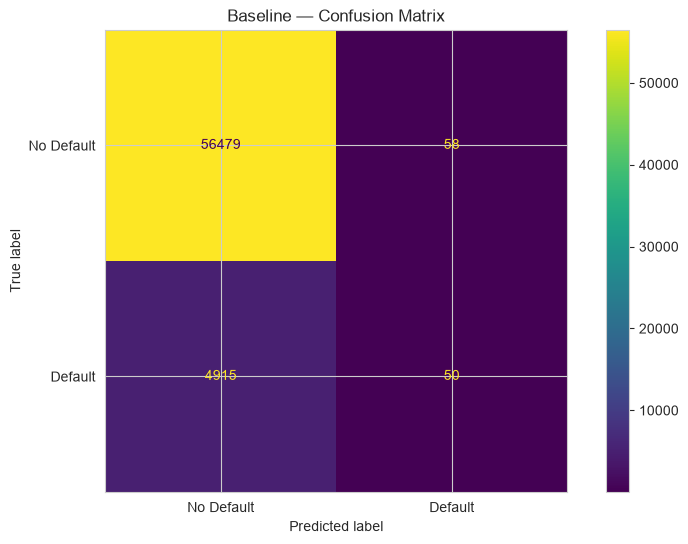

In [35]:
# ------------------------------------------------------------------
#  Baseline Logistic Regression (no imbalance handling)
# ------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

y_pred_baseline    = lr_baseline.predict(X_test_scaled)
y_proba_baseline   = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("=== Baseline Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Baseline — Confusion Matrix")
plt.show()

**LOGISTIC REGRESSION (CLASS WEIGHTING**)

=== Class Weighted Logistic Regression ===
ROC-AUC: 0.7459
              precision    recall  f1-score   support

  No Default       0.96      0.68      0.80     56537
     Default       0.16      0.68      0.26      4965

    accuracy                           0.68     61502
   macro avg       0.56      0.68      0.53     61502
weighted avg       0.90      0.68      0.75     61502



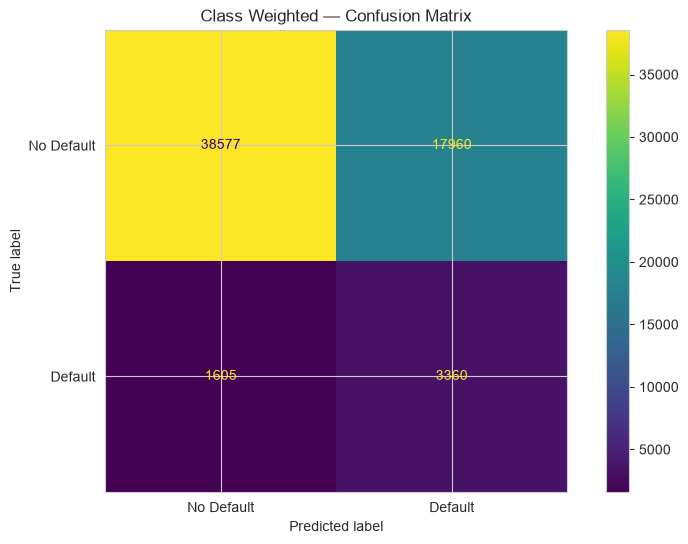

In [40]:
# ------------------------------------------------------------------
#  Class Weighted Logistic Regression
# ------------------------------------------------------------------
lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight={0: 0.08, 1: 0.92})
lr_weighted.fit(X_train_scaled, y_train)

y_pred_weighted  = lr_weighted.predict(X_test_scaled)
y_proba_weighted = lr_weighted.predict_proba(X_test_scaled)[:, 1]

print("=== Class Weighted Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_weighted):.4f}")
print(classification_report(y_test, y_pred_weighted, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_weighted)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Class Weighted — Confusion Matrix")
plt.show()

**LOGISTIC REGRESION (SMOTE)**

After SMOTE — Train shape: (452290, 59)
Class distribution: {0: 226145, 1: 226145}

=== SMOTE Logistic Regression ===
ROC-AUC: 0.7409
              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56537
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61502
   macro avg       0.56      0.68      0.53     61502
weighted avg       0.89      0.69      0.76     61502



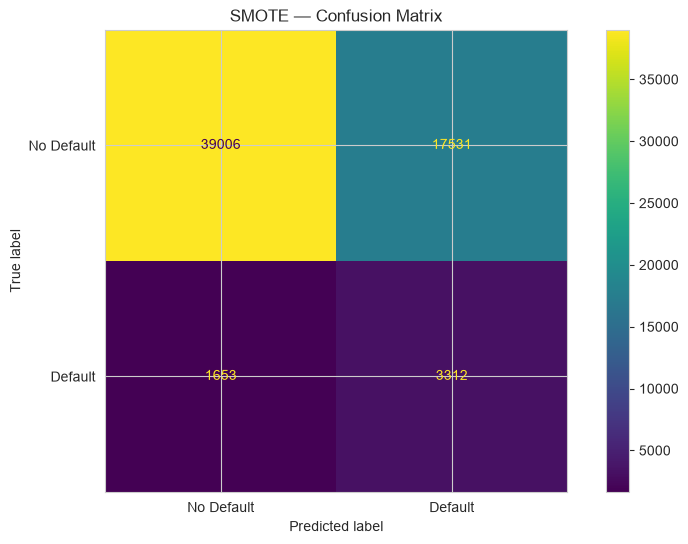

In [58]:
# ------------------------------------------------------------------
#  SMOTE + Logistic Regression
# ------------------------------------------------------------------
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE — Train shape: {X_train_smote.shape}")
print(f"Class distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote  = lr_smote.predict(X_test_scaled)
y_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== SMOTE Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_smote):.4f}")
print(classification_report(y_test, y_pred_smote, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_smote)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("SMOTE — Confusion Matrix")
plt.show()

In [59]:
# ------------------------------------------------------------------
# Summary comparison
# ------------------------------------------------------------------
summary = pd.DataFrame({
    "Model": ["Baseline", "Class Weighted", "SMOTE"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_baseline),
        roc_auc_score(y_test, y_proba_weighted),
        roc_auc_score(y_test, y_proba_smote),
    ]
})
print(summary.to_string(index=False))

         Model  ROC-AUC
      Baseline 0.746063
Class Weighted 0.745882
         SMOTE 0.740868
